## Picking

In [1]:
import tensorflow as tf
from recovar import RepresentationLearningMultipleAutoencoder
import matplotlib.pyplot as plt
import numpy as np

2025-10-31 23:46:23.342330: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-31 23:46:23.376365: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-31 23:46:23.376406: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-31 23:46:23.376435: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-31 23:46:23.383462: I tensorflow/core/platform/cpu_feature_g

In [ ]:
model = RepresentationLearningMultipleAutoencoder()
model.load_weights('path/to/checkpoint')

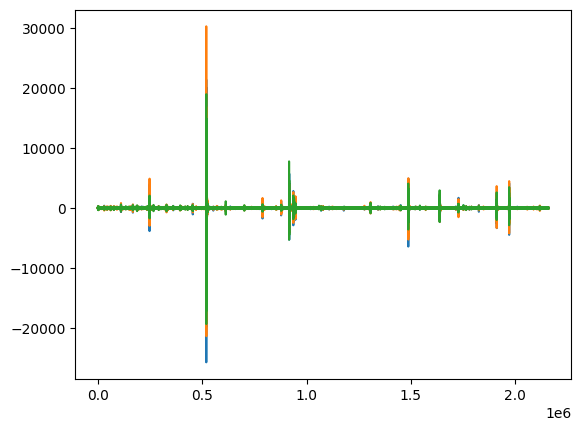

In [6]:
waveform = np.load("/home/ege/27AUGUST/KO_BALB.npy")
plt.plot(waveform);

In [8]:
waveform.shape

(2160087, 3)

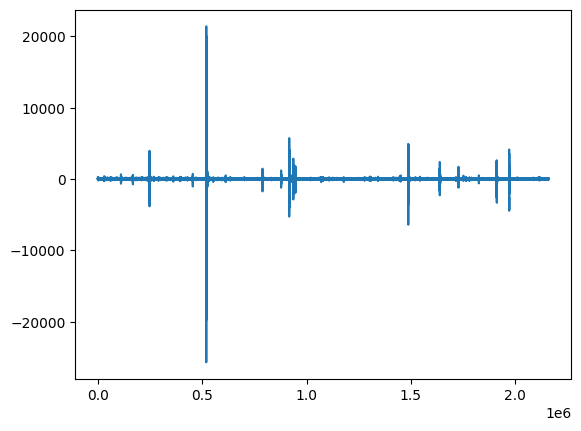

In [10]:
plt.plot(waveform[:, 0]);

In [ ]:
results = model(waveform, training=False)

In [ ]:
*_, log_p, surprise, pick_index, pickability_score = results

print(f"P wave arrival at sample: {pick_index.numpy()}")
print(f"Confidence (pickability score): {pickability_score.numpy():.2f}")

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(2, 1, 1)
plt.plot(waveform[:, 0])
plt.axvline(pick_index, color='red', label='Picked P arrival')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(surprise.numpy())
plt.axvline(pick_index, color='red')
plt.ylabel('Surprise')
plt.show()